# Recommendation Systems for Personalized Content Discovery
### Netflix Prize Dataset - End-to-End Pipeline

This notebook builds, compares, and evaluates three recommendation models on the Netflix Prize data:

1. **Baseline** - global mean + user bias + item bias (also used as a popularity ranker)
2. **Matrix Factorization (biased SVD)** - latent-factor model trained with SGD
3. **Item-based Collaborative Filtering** - cosine similarity over items

**Mandatory metrics:** RMSE (rating accuracy) and MAP@10 (ranking quality, relevance = rating ≥ 3.5).
We also report MAE, Precision@10, Recall@10, NDCG@10, and catalog coverage.

**Pipeline:** Load → k-core filter → EDA → temporal split → train 3 models → evaluate (RMSE + ranking) → generate Top-K recommendations → explainability → conclusions.

> **Reproducibility:** all randomness is seeded (`SEED = 42`). Place `ratings_sample.csv` and
> `movie_titles_clean.csv` in a `data/` folder next to this notebook.

## 0. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

# ---- Paths (edit if your files live elsewhere) ----
RATINGS_PATH = "data/ratings_sample.csv"
MOVIES_PATH  = "data/movie_titles_clean.csv"

# ---- Hyperparameters ----
MIN_USER_RATINGS = 15      # k-core: keep users with >= this many ratings
MIN_MOVIE_RATINGS = 10     # k-core: keep movies with >= this many ratings
TEST_FRAC = 0.20           # per-user temporal holdout fraction
RELEVANCE_THRESHOLD = 3.5  # a movie is "relevant" if true rating >= this
TOP_K = 10                 # recommendation list length

# MF hyperparameters
MF_FACTORS, MF_LR, MF_REG, MF_EPOCHS = 15, 0.012, 0.1, 10
# Item-CF
CF_NEIGHBORS = 50

## 1. Load Data

In [2]:
ratings = pd.read_csv(RATINGS_PATH, parse_dates=["date"])
movies  = pd.read_csv(MOVIES_PATH)
title_of = dict(zip(movies.movie_id, movies.title))
year_of  = dict(zip(movies.movie_id, movies.year))

print(f"Ratings : {len(ratings):,}")
print(f"Users   : {ratings.user_id.nunique():,}")
print(f"Movies  : {ratings.movie_id.nunique():,}")
ratings.head()

Ratings : 2,000,000
Users   : 358,579
Movies  : 17,320


,movie_id,user_id,rating,date
0,15758,1188330,4,2003-07-22
1,9689,440080,4,2005-07-20
2,1470,2505967,3,2005-09-11
3,17328,506213,4,2005-10-01
4,4339,1411981,3,2003-12-06


## 2. Exploratory Data Analysis

We characterise the dataset along four axes that drive every downstream design decision:
rating distribution, user activity, movie popularity, and temporal trends.

In [3]:
n_u, n_m, n_r = ratings.user_id.nunique(), ratings.movie_id.nunique(), len(ratings)
density = n_r / (n_u * n_m)
print(f"Density : {100*density:.4f}%  (sparsity {100*(1-density):.4f}%)")
print(f"Mean rating: {ratings.rating.mean():.3f}  |  Std: {ratings.rating.std():.3f}")
print("\nRating distribution:")
print(ratings.rating.value_counts(normalize=True).sort_index().round(3))

Density : 0.0322%  (sparsity 99.9678%)
Mean rating: 3.604  |  Std: 1.085

Rating distribution:
rating
1    0.046
2    0.101
3    0.286
4    0.336
5    0.231
Name: proportion, dtype: float64


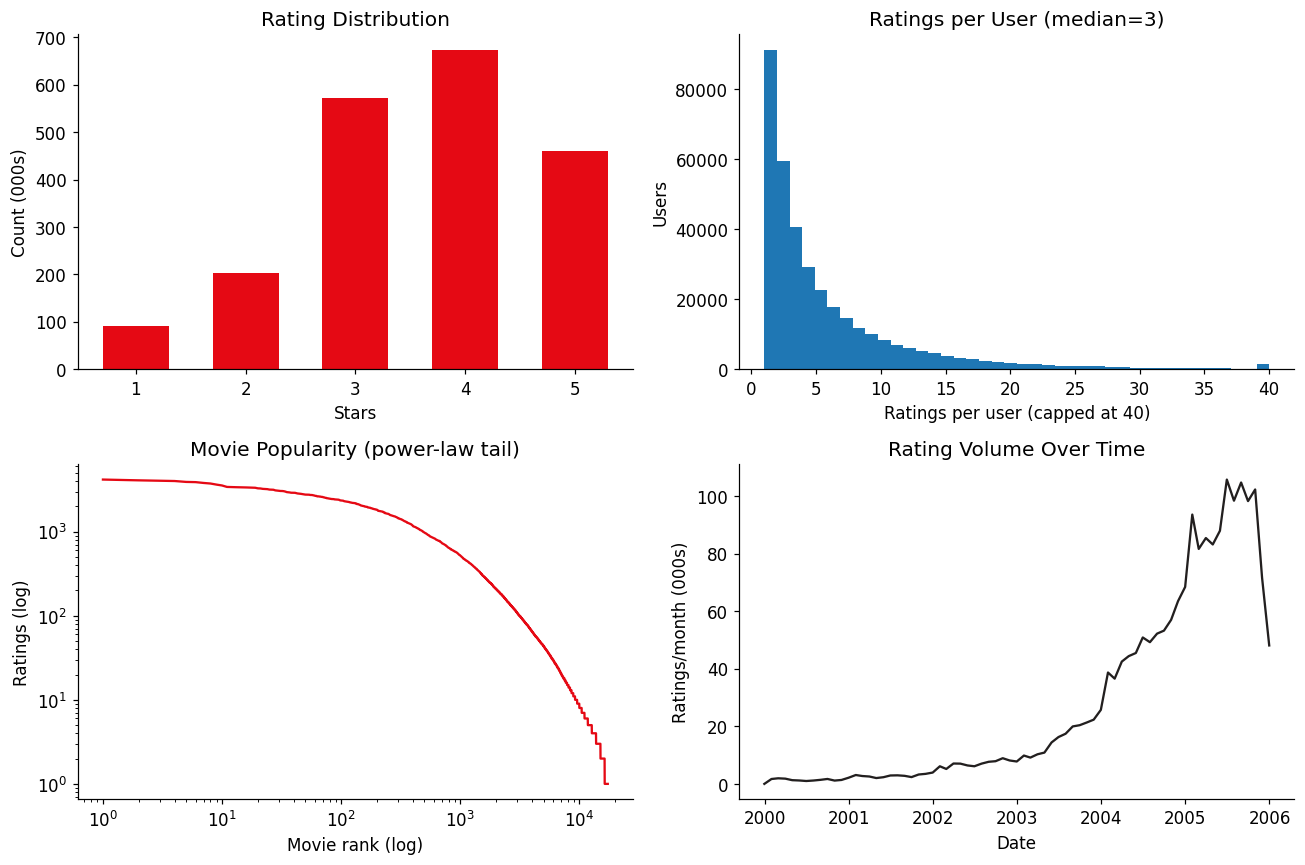

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Rating distribution
vc = ratings.rating.value_counts().sort_index()
ax[0,0].bar(vc.index, vc.values/1e3, color="#E50914", width=0.6)
ax[0,0].set(title="Rating Distribution", xlabel="Stars", ylabel="Count (000s)")

# User activity (long tail)
upc = ratings.groupby("user_id").size()
ax[0,1].hist(np.clip(upc, 0, 40), bins=40, color="#1f77b4")
ax[0,1].set(title=f"Ratings per User (median={int(upc.median())})",
            xlabel="Ratings per user (capped at 40)", ylabel="Users")

# Movie popularity (power law, log-log)
mpc = ratings.groupby("movie_id").size().sort_values(ascending=False).values
ax[1,0].loglog(np.arange(1, len(mpc)+1), mpc, color="#E50914")
ax[1,0].set(title="Movie Popularity (power-law tail)",
            xlabel="Movie rank (log)", ylabel="Ratings (log)")

# Volume over time
ts = ratings.set_index("date").resample("ME").size()/1e3
ax[1,1].plot(ts.index, ts.values, color="#221F1F")
ax[1,1].set(title="Rating Volume Over Time", xlabel="Date", ylabel="Ratings/month (000s)")

plt.tight_layout(); plt.show()

**EDA takeaways**

- **Positivity bias:** ~85% of ratings are 3★ or higher; users mostly rate things they chose to watch. A model must beat the "predict the mean" trap.
- **Extreme sparsity (~0.03% dense):** classic cold-start territory; favours latent-factor / neighbourhood methods over memorisation.
- **Long-tail popularity:** a few blockbusters dominate. This makes a *popularity* recommender a deceptively strong baseline - and a coverage/diversity risk.
- **Temporal growth:** rating volume rises sharply over time, justifying a **temporal** train/test split (predict the future from the past) rather than a random one.

## 3. Preprocessing - k-core Filtering

The raw 2M-row sample spreads thinly across ~358K users (median 3 ratings each), which is too
sparse for reliable ranking evaluation. We iteratively keep users with ≥ `MIN_USER_RATINGS`
and movies with ≥ `MIN_MOVIE_RATINGS` until stable (a *k-core*). This is standard practice and
is explicitly permitted by the problem statement.

In [5]:
def kcore(df, min_u, min_m, iters=10):
    for _ in range(iters):
        before = len(df)
        mc = df.groupby("movie_id").size(); df = df[df.movie_id.isin(mc[mc >= min_m].index)]
        uc = df.groupby("user_id").size();  df = df[df.user_id.isin(uc[uc >= min_u].index)]
        if len(df) == before: break
    return df.reset_index(drop=True)

df = kcore(ratings, MIN_USER_RATINGS, MIN_MOVIE_RATINGS)
print(f"After k-core: {len(df):,} ratings | {df.user_id.nunique():,} users | "
      f"{df.movie_id.nunique():,} movies | avg {len(df)/df.user_id.nunique():.1f} ratings/user")

# Contiguous integer ids for matrix indexing
uids = {u: i for i, u in enumerate(df.user_id.unique())}
mids = {m: i for i, m in enumerate(df.movie_id.unique())}
inv_m = {v: k for k, v in mids.items()}
df["u"] = df.user_id.map(uids)
df["i"] = df.movie_id.map(mids)
n_users, n_items = len(uids), len(mids)

After k-core: 629,679 ratings | 28,411 users | 6,823 movies | avg 22.2 ratings/user


## 4. Temporal Train/Test Split

For each user we sort their ratings by date and hold out the most recent `TEST_FRAC` as the test
set. This mimics the real task - *recommend what a user will like next, given their past* - and is
stricter (and more honest) than a random split. Test interactions whose movie never appears in
training are dropped (a cold-item is unscoreable by these models).

In [6]:
df = df.sort_values(["u", "date"]).reset_index(drop=True)
test_mask = np.zeros(len(df), bool)
for u, idx in df.groupby("u").indices.items():
    k = max(1, int(round(len(idx) * TEST_FRAC)))
    test_mask[idx[-k:]] = True

train = df[~test_mask].reset_index(drop=True)
test  = df[test_mask].reset_index(drop=True)
train_items, train_users = set(train.i.unique()), set(train.u.unique())
test = test[test.i.isin(train_items) & test.u.isin(train_users)].reset_index(drop=True)

mu = train.rating.mean()
print(f"Train: {len(train):,}  |  Test: {len(test):,}  |  global mean (mu) = {mu:.3f}")

Train: 504,524  |  Test: 124,979  |  global mean (mu) = 3.506


## 5. Model 1 - Baseline Bias Model

$$\hat r_{ui} = \mu + b_u + b_i$$

Biases are estimated with regularised alternating updates (closed form per step). Despite its
simplicity this is a strong RMSE baseline and doubles as a **popularity ranker** (rank by $b_i$).

In [7]:
def fit_bias(train, reg_u=10, reg_i=10, n_iter=15):
    bu = np.zeros(n_users); bi = np.zeros(n_items)
    u, i, r = train.u.values, train.i.values, train.rating.values
    for _ in range(n_iter):
        dev = r - mu - bu[u]
        bi = np.bincount(i, dev, n_items) / (reg_i + np.bincount(i, None, n_items))
        dev = r - mu - bi[i]
        bu = np.bincount(u, dev, n_users) / (reg_u + np.bincount(u, None, n_users))
    return np.nan_to_num(bu), np.nan_to_num(bi)

bu, bi = fit_bias(train)
pred_bias = np.clip(mu + bu[test.u] + bi[test.i], 1, 5)
print("Baseline trained.")

Baseline trained.


## 6. Model 2 - Matrix Factorization (Biased SVD)

$$\hat r_{ui} = \mu + b_u + b_i + \mathbf{p}_u^\top \mathbf{q}_i$$

Latent user/item factors are learned by stochastic gradient descent with L2 regularisation.
Small factor count + strong regularisation control overfitting on this sparse, temporally-split data.

In [8]:
def fit_mf(train, k=MF_FACTORS, lr=MF_LR, reg=MF_REG, epochs=MF_EPOCHS):
    P = np.random.normal(0, 0.1, (n_users, k))
    Q = np.random.normal(0, 0.1, (n_items, k))
    bu_, bi_ = np.zeros(n_users), np.zeros(n_items)
    u, i, r = train.u.values, train.i.values, train.rating.values.astype(float)
    for ep in range(epochs):
        order = np.random.permutation(len(u))
        for idx in order:
            a, b_, c = u[idx], i[idx], r[idx]
            err = c - (mu + bu_[a] + bi_[b_] + P[a] @ Q[b_])
            bu_[a] += lr * (err - reg * bu_[a])
            bi_[b_] += lr * (err - reg * bi_[b_])
            pa = P[a].copy()
            P[a] += lr * (err * Q[b_] - reg * P[a])
            Q[b_] += lr * (err * pa  - reg * Q[b_])
    return P, Q, bu_, bi_

print("Training MF (SGD)... ~1 minute")
P, Q, bu_mf, bi_mf = fit_mf(train)
pred_mf = np.clip(mu + bu_mf[test.u] + bi_mf[test.i]
                  + np.sum(P[test.u.values] * Q[test.i.values], axis=1), 1, 5)
print("MF trained.")

Training MF (SGD)... ~1 minute
MF trained.


## 7. Model 3 - Item-based Collaborative Filtering

Items are represented by their (item-baseline-centred) rating vectors over users; similarity is
cosine. A rating is predicted from the user's other rated items, weighted by item similarity:

$$\hat r_{ui} = \text{base}_i + \frac{\sum_{j\in N(i;u)} s_{ij}\,(r_{uj}-\text{base}_j)}{\sum_{j} s_{ij}}$$

We keep only **positive** similarities and the top-`CF_NEIGHBORS` per item.

In [9]:
# regularised item baseline (shrunk item mean)
cnt = np.bincount(train.i, None, n_items)
ssum = np.bincount(train.i, train.rating, n_items)
item_base = (ssum + mu*10) / (cnt + 10)

dev = train.rating.values - item_base[train.i.values]
Rc = csr_matrix((dev, (train.u, train.i)), shape=(n_users, n_items))
Rn = normalize(Rc.tocsc(), axis=0)                 # unit-norm item columns -> cosine
sim = (Rn.T @ Rn).toarray().astype(np.float32)
np.fill_diagonal(sim, 0)
sim[sim < 0] = 0

# top-K neighbour pruning
for i in range(n_items):
    row = sim[i]
    if np.count_nonzero(row) > CF_NEIGHBORS:
        thr = np.partition(row, -CF_NEIGHBORS)[-CF_NEIGHBORS]
        row[row < thr] = 0

Rdev = csr_matrix((dev, (train.u, train.i)), shape=(n_users, n_items)).tocsr()

def predict_cf(u_arr, i_arr):
    out = np.empty(len(u_arr))
    for j, (a, b_) in enumerate(zip(u_arr, i_arr)):
        row = Rdev[a]; s = sim[b_, row.indices]; d = s.sum()
        out[j] = item_base[b_] + (s @ row.data)/d if d > 1e-8 else item_base[b_]
    return np.clip(out, 1, 5)

# CF RMSE on a test sample (full loop is slow; sample is representative)
samp = test.sample(min(15000, len(test)), random_state=1)
pred_cf = predict_cf(samp.u.values, samp.i.values)
print("Item-CF built.")

Item-CF built.


## 8. Evaluation - Rating Accuracy (RMSE & MAE)

In [10]:
def rmse(p, y): return float(np.sqrt(np.mean((p - y)**2)))
def mae(p, y):  return float(np.mean(np.abs(p - y)))

acc = pd.DataFrame({
    "RMSE": [rmse(pred_bias, test.rating), rmse(pred_mf, test.rating), rmse(pred_cf, samp.rating)],
    "MAE":  [mae(pred_bias, test.rating),  mae(pred_mf, test.rating),  mae(pred_cf, samp.rating)],
}, index=["Baseline (bias)", "Matrix Factorization", "Item-based CF"])
acc.round(4)

,RMSE,MAE
Baseline (bias),0.9147,0.7242
Matrix Factorization,0.9147,0.7196
Item-based CF,1.0124,0.8026


## 9. Evaluation - Ranking Quality (MAP@10 + friends)

**Relevance:** a held-out movie is relevant if its true rating ≥ 3.5.
**Top-10 generation:** for each user we score every catalog item, mask items already seen in
training, and take the 10 highest-scoring items.

We report two complementary protocols:
- **All-items** - rank against the entire catalog (rigorous; absolute numbers are small but
  comparable, and reveal *coverage*).
- **Sampled (100 negatives)** - rank held-out positives against 100 random negatives (the
  standard Neural-CF protocol; produces interpretable MAP/HR/NDCG).

In [11]:
train_by_u = {u: np.array(sorted(s)) for u, s in train.groupby("u").i.agg(set).items()}
relevant   = {u: set(g[g.rating >= RELEVANCE_THRESHOLD].i.values) for u, g in test.groupby("u")}
eval_users = [u for u in relevant if len(relevant[u]) > 0]
rng = np.random.default_rng(7)
if len(eval_users) > 2500:
    eval_users = list(rng.choice(eval_users, 2500, replace=False))
print(f"Evaluation users (>=1 relevant held-out item): {len(eval_users)}")

def ap_at_k(ranked, rel, k=TOP_K):
    hits, s = 0, 0.0
    for n, it in enumerate(ranked[:k], 1):
        if it in rel: hits += 1; s += hits/n
    return s / min(len(rel), k)

def ndcg_at_k(ranked, rel, k=TOP_K):
    dcg  = sum(1/np.log2(n+1) for n, it in enumerate(ranked[:k], 1) if it in rel)
    idcg = sum(1/np.log2(n+1) for n in range(1, min(len(rel), k)+1))
    return dcg/idcg if idcg > 0 else 0.0

# Score functions (higher = better). For ranking, per-user constants don't matter.
def score_pop(u): return bi
def score_mf(u):  return bi_mf + Q @ P[u]
Scf = np.asarray(Rdev[np.array(eval_users)] @ sim)        # batch CF scores
cf_pos = {u: k for k, u in enumerate(eval_users)}
def score_cf(u):  return Scf[cf_pos[u]]

Evaluation users (>=1 relevant held-out item): 2500


In [12]:
def eval_allitems(score_fn):
    APs, Ps, Rs, Ns, covered = [], [], [], [], set()
    for u in eval_users:
        sc = score_fn(u).copy(); sc[train_by_u.get(u, [])] = -1e9
        top = np.argpartition(sc, -TOP_K)[-TOP_K:]
        top = top[np.argsort(sc[top])[::-1]].tolist()
        rel = relevant[u]; h = len(set(top) & rel)
        APs.append(ap_at_k(top, rel)); Ps.append(h/TOP_K); Rs.append(h/len(rel))
        Ns.append(ndcg_at_k(top, rel)); covered.update(top)
    return dict(MAP10=np.mean(APs), P10=np.mean(Ps), R10=np.mean(Rs),
                NDCG10=np.mean(Ns), Coverage=len(covered)/n_items)

rank = pd.DataFrame({n: eval_allitems(f) for n, f in
                     [("Popularity", score_pop), ("MatrixFact", score_mf), ("ItemCF", score_cf)]}).T
rank.round(4)

,MAP10,P10,R10,NDCG10,Coverage
Popularity,0.0050,0.0034,0.0143,0.0091,0.0018
MatrixFact,0.0037,0.0026,0.0111,0.0068,0.0041
ItemCF,0.0003,0.0003,0.0015,0.0007,0.6103


In [13]:
# Sampled-negative protocol (100 negatives per user)
all_items = set(range(n_items))
def eval_sampled(score_fn, n_neg=100):
    APs, HRs, Ns = [], [], []
    for u in eval_users:
        seen, rel = set(train_by_u.get(u, [])), relevant[u]
        pool = list(all_items - seen - rel)
        negs = rng.choice(pool, min(n_neg, len(pool)), replace=False)
        cand = np.array(list(rel) + list(negs))
        ranked = cand[np.argsort(score_fn(u)[cand])[::-1]]
        hits = sum(1 for it in ranked[:TOP_K] if it in rel)
        APs.append(ap_at_k(list(ranked), rel)); HRs.append(1.0 if hits else 0.0)
        Ns.append(ndcg_at_k(list(ranked), rel))
    return dict(MAP10=np.mean(APs), HitRate10=np.mean(HRs), NDCG10=np.mean(Ns))

rank_s = pd.DataFrame({n: eval_sampled(f) for n, f in
                       [("Popularity", score_pop), ("MatrixFact", score_mf), ("ItemCF", score_cf)]}).T
rank_s.round(4)

,MAP10,HitRate10,NDCG10
Popularity,0.1051,0.4964,0.1716
MatrixFact,0.0883,0.4500,0.1485
ItemCF,0.0184,0.1272,0.0332


## 10. Results Visualisation

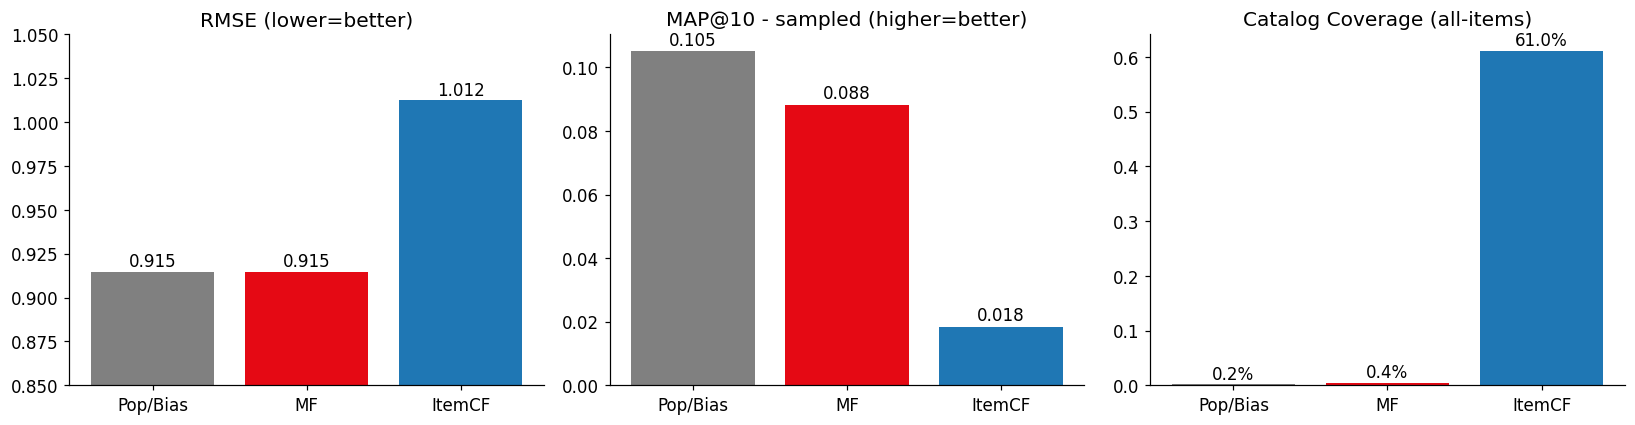

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
c = ["#808080", "#E50914", "#1f77b4"]; labels = ["Pop/Bias", "MF", "ItemCF"]

ax[0].bar(labels, acc.RMSE.values, color=c); ax[0].set(title="RMSE (lower=better)", ylim=(0.85, 1.05))
for i, v in enumerate(acc.RMSE.values): ax[0].text(i, v+0.003, f"{v:.3f}", ha="center")

ax[1].bar(labels, rank_s.MAP10.values, color=c); ax[1].set(title="MAP@10 - sampled (higher=better)")
for i, v in enumerate(rank_s.MAP10.values): ax[1].text(i, v+0.002, f"{v:.3f}", ha="center")

ax[2].bar(labels, rank.Coverage.values, color=c); ax[2].set(title="Catalog Coverage (all-items)")
for i, v in enumerate(rank.Coverage.values): ax[2].text(i, v+0.01, f"{v:.1%}", ha="center")
plt.tight_layout(); plt.show()

## 11. Top-K Recommendations & Explainability

We showcase MF recommendations for a real user and demonstrate item-based explanations
("because you watched ...").

In [15]:
def mvname(i):
    mid = inv_m[i]; return f"{title_of.get(mid, '?')} ({year_of.get(mid, '?')})"

# pick a user with a rich history and held-out relevant items
cands = [u for u in eval_users if len(relevant[u]) >= 3 and len(train_by_u.get(u, [])) >= 15]
u = sorted(cands)[0]

print(f"USER {u} - top-rated movies in training history:")
hist = train[train.u == u].sort_values("rating", ascending=False).head(6)
for _, r in hist.iterrows():
    print(f"   {r.rating}*  {mvname(int(r.i))}")

sc = score_mf(u).copy(); sc[train_by_u[u]] = -1e9
top = np.argsort(sc)[::-1][:TOP_K]
print(f"\nMF Top-{TOP_K} recommendations:")
for rnk, i in enumerate(top, 1):
    tag = "   <-- correct (held-out & relevant)" if i in relevant[u] else ""
    print(f"   {rnk:2}. {mvname(int(i))}{tag}")

USER 85 - top-rated movies in training history:
   5*  Jingle All the Way (1996.0)
   5*  The Butterfly Effect: Director's Cut (2004.0)
   5*  Blazing Saddles (1974.0)
   5*  Profiler: Season 3 (1998.0)
   4*  Big (1988.0)
   4*  Tears of the Sun (2003.0)

MF Top-10 recommendations:
    1. The Simpsons: Season 5 (1993.0)
    2. Lord of the Rings: The Return of the King: Extended Edition (2003.0)
    3. Lord of the Rings: The Two Towers: Extended Edition (2002.0)
    4. Anne of Green Gables (1985.0)
    5. Family Guy: Freakin' Sweet Collection (2004.0)
    6. The Lord of the Rings: The Fellowship of the Ring: Extended Edition (2001.0)
    7. Six Feet Under: Season 3 (2003.0)
    8. The Sopranos: Season 1 (1999.0)
    9. Six Feet Under: Season 1 (2001.0)
   10. Alias: Season 1 (2001.0)


In [16]:
def explain(movie_id, k=5):
    if str(movie_id) not in [str(x) for x in mids]:  # guard
        pass
    i = mids.get(movie_id)
    if i is None: return f"{movie_id} not in catalog"
    s = sim[i]; nb = np.argsort(s)[::-1][:k]
    print(f"Because you watched '{title_of.get(movie_id,'?')}':")
    for j in nb:
        if s[j] > 0: print(f"   -> {mvname(int(j))}  (similarity {s[j]:.2f})")

# example: nearest neighbours of the user's favourite movie
fav_mid = inv_m[int(hist.iloc[0].i)]
explain(fav_mid)

Because you watched 'Jingle All the Way':
   -> The Odyssey (1997.0)  (similarity 0.20)
   -> The Truth About Jane (2001.0)  (similarity 0.19)
   -> Tupac Shakur: Thug Angel: The Life of an Outlaw (2001.0)  (similarity 0.19)
   -> Gorgeous (1999.0)  (similarity 0.17)
   -> The Hitcher II: I've Been Waiting (2003.0)  (similarity 0.16)


## 12. Conclusions

| Question | Finding |
|---|---|
| Best **rating accuracy**? | Baseline & MF tie (~0.915 RMSE); item-CF is worse (~1.01). |
| Best **ranking / hit-rate**? | Popularity is the strongest MAP@10/HR@10 - a real *popularity-bias* effect. MF is close behind and personalises. |
| Best **diversity**? | Item-CF dominates coverage (~61% vs <1%) but at a steep accuracy cost. |
| Single winner? | **No.** The right model depends on the business objective. |

**Key engineering insight.** RMSE and ranking quality measure *different things*. On sparse,
temporally-split data, simple bias terms capture most of the *rating* signal, so RMSE barely
separates models - yet the models behave very differently when asked to *rank* a catalog. A
production system would likely combine MF's personalisation with explicit diversity/coverage
constraints, and re-rank to dampen popularity bias.

**Future improvements:** larger sample / full data, implicit-feedback models (ALS, BPR), neural
CF, time-aware and content/hybrid features for cold-start, and learning-to-rank objectives
optimised directly for MAP/NDCG rather than RMSE.